In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("27-mall_customers.csv")

In [6]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

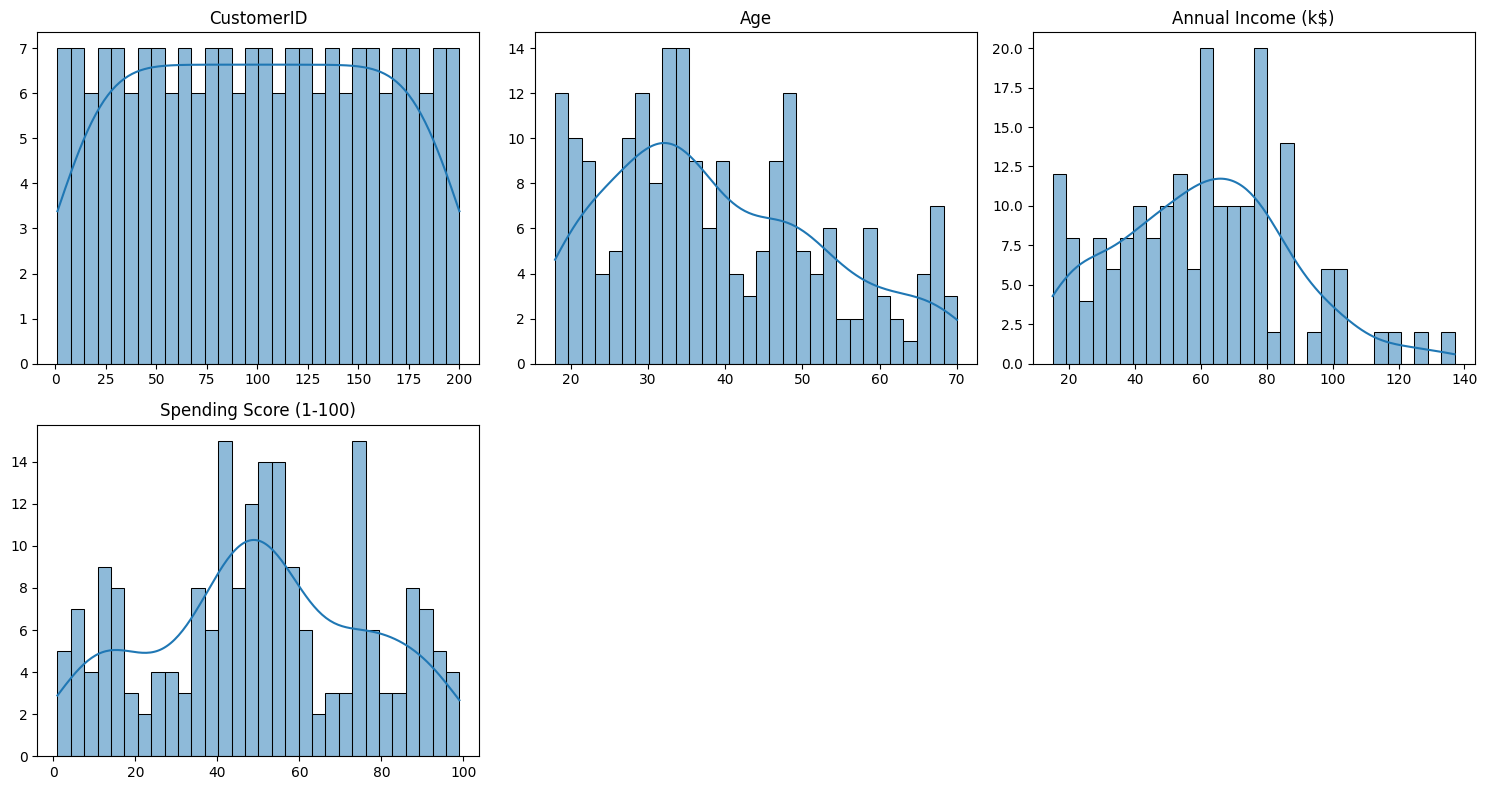

In [8]:
plot_all_histograms(df)

In [9]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [12]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [13]:
df = df.drop("CustomerID", axis=1)

In [14]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [16]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [19]:
df = pd.DataFrame(df_scaled, columns = df.columns)

In [23]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980
...,...,...,...,...
195,-0.886405,-0.276302,2.268791,1.118061
196,-0.886405,0.441365,2.497807,-0.861839
197,1.128152,-0.491602,2.497807,0.923953
198,1.128152,-0.491602,2.917671,-1.250054


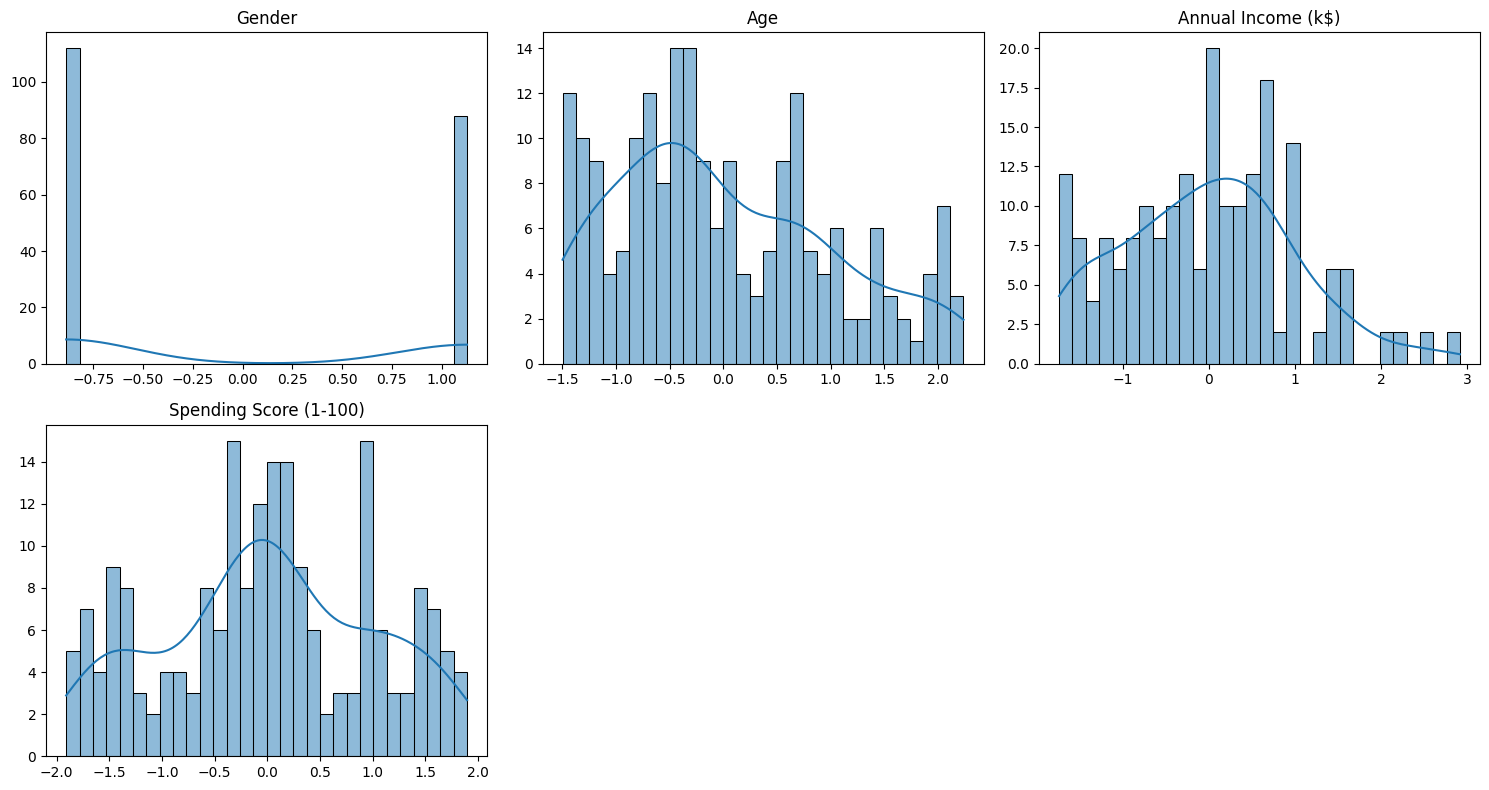

In [24]:
plot_all_histograms(df)

In [25]:
import scipy.cluster.hierarchy as sch

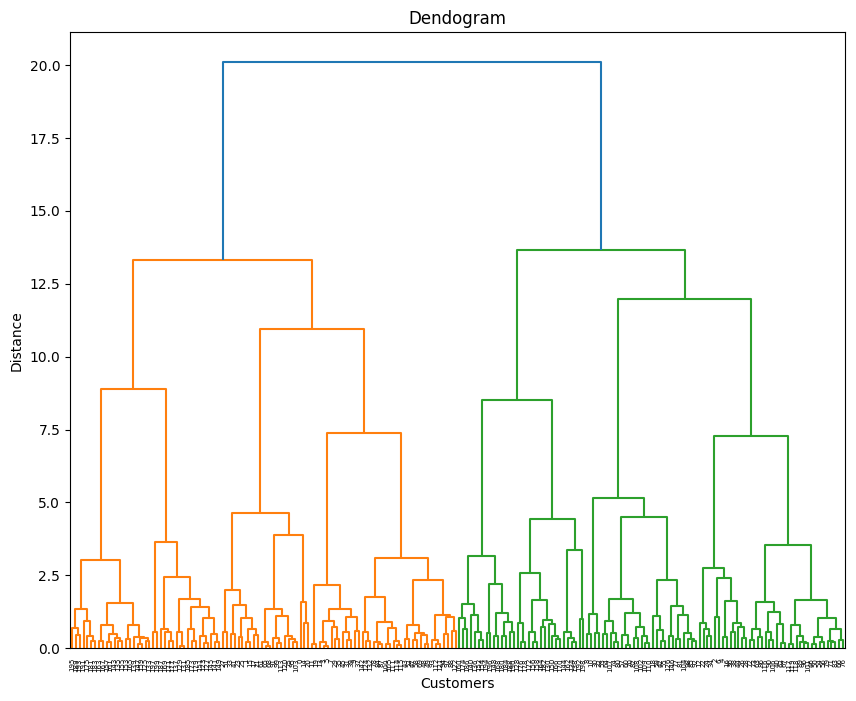

In [28]:
plt.figure(1, figsize = (10,8))
dendrogram = sch.dendrogram(sch.linkage(df, method = "ward"))
plt.title("Dendogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [29]:
from sklearn.cluster import AgglomerativeClustering

In [30]:
hc = AgglomerativeClustering(n_clusters = 4)

In [34]:
hc = hc.fit(df)

In [37]:
y_hc = hc.fit_predict(df)

In [38]:
y_hc

array([1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 3, 1, 3, 0, 3, 2, 3, 2, 3,
       1, 3, 2, 3, 2, 3, 2, 3, 2, 3, 1, 3, 2, 3, 0, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3])

In [39]:
df["cluster"] = pd.DataFrame(y_hc)

In [40]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1.128152,-1.424569,-1.738999,-0.434801,1
1,1.128152,-1.281035,-1.738999,1.195704,1
2,-0.886405,-1.352802,-1.700830,-1.715913,0
3,-0.886405,-1.137502,-1.700830,1.040418,1
4,-0.886405,-0.563369,-1.662660,-0.395980,0


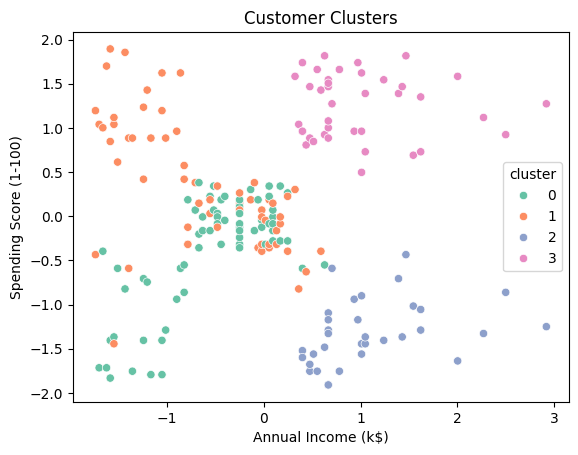

In [42]:
sns.scatterplot(data=df, x = "Annual Income (k$)", y="Spending Score (1-100)", hue="cluster", palette = "Set2")
plt.title("Customer Clusters")
plt.show()

In [44]:
from sklearn.metrics import silhouette_score
print(silhouette_score(df, y_hc))

0.3703327740669248


In [47]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()

In [48]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


In [53]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X)
X["cluster"] = y_hc

In [54]:
X

,Annual Income (k$),Spending Score (1-100),cluster
0,-1.738999,-0.434801,4
1,-1.738999,1.195704,3
2,-1.700830,-1.715913,4
3,-1.700830,1.040418,3
4,-1.662660,-0.395980,4
...,...,...,...
195,2.268791,1.118061,1
196,2.497807,-0.861839,0
197,2.497807,0.923953,1
198,2.917671,-1.250054,0


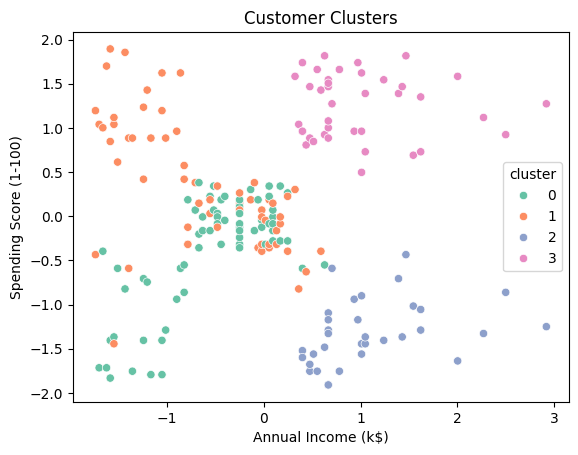

In [55]:
sns.scatterplot(data=df, x = "Annual Income (k$)", y="Spending Score (1-100)", hue="cluster", palette = "Set2")
plt.title("Customer Clusters")
plt.show()

In [57]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'cluster'],
      dtype='object')

In [56]:
print(silhouette_score(X, y_hc))

0.6683754206366561


In [64]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

In [65]:
df = pd.read_csv("27-mall_customers.csv")
df = df.drop("CustomerID", axis=1)
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

features_2d = ['Annual Income (k$)', 'Spending Score (1-100)']
features_3d = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
features_4d = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for feats in [features_2d, features_3d, features_4d]:
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    hc = AgglomerativeClustering(n_clusters = 5)
    y_hc = hc.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, y_hc)
    db = davies_bouldin_score(X_scaled, y_hc)
    ch = calinski_harabasz_score(X_scaled, y_hc)

    print(f"features: {feats}")
    print("sil: ",sil)
    print("db: ",db)
    print("ch: ",ch)

features: ['Annual Income (k$)', 'Spending Score (1-100)']
sil:  0.5582698727324805
db:  0.5734519252471812
ch:  258.97400737720704
features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
sil:  0.3955454334726548
db:  0.8746143334035466
ch:  123.99070840826577
features: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
sil:  0.35032447507156306
db:  1.0941951795238574
ch:  163.46602356383625


In [66]:
from sklearn.cluster import KMeans

In [67]:
df = pd.read_csv("27-mall_customers.csv")
df = df.drop("CustomerID", axis=1)
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

features_2d = ['Annual Income (k$)', 'Spending Score (1-100)']
features_3d = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
features_4d = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for feats in [features_2d, features_3d, features_4d]:
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    kmeans = KMeans(n_clusters = 5)
    y_hc = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, y_hc)
    db = davies_bouldin_score(X_scaled, y_hc)
    ch = calinski_harabasz_score(X_scaled, y_hc)

    print(f"features: {feats}")
    print("sil: ",sil)
    print("db: ",db)
    print("ch: ",ch)

features: ['Annual Income (k$)', 'Spending Score (1-100)']
sil:  0.5593469429181728
db:  0.5616471225010367
ch:  264.5506476775084
features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
sil:  0.3545381196986157
db:  1.0548095304759475
ch:  108.91984695167719
features: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
sil:  0.35787808216718503
db:  1.095037781748706
ch:  162.92444985917416
